# Pipeline ML — Prédiction du risque d'annulation
**Maeva — Mastère 2 DIA Paris**

Pipeline complet :
1. Chargement & nettoyage
2. Feature engineering (variables dérivées)
3. Gestion du déséquilibre (SMOTE + class_weight)
4. Préprocessing (imputation, scaling, OHE)
5. Entraînement de 3 modèles (LR → RF → XGBoost)
6. Optimisation des hyperparamètres (RandomizedSearchCV)
7. Évaluation complète (ROC, PR, matrice de confusion)
8. Interprétabilité SHAP
9. Export du modèle final

---

## 0. Installation

In [1]:
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap imbalanced-learn joblib

## 1. Imports & configuration

In [2]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

# Préprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Gestion déséquilibre
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métriques
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, precision_score, recall_score
)
from sklearn.metrics import make_scorer

# Interprétabilité
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
os.makedirs('figures', exist_ok=True)
os.makedirs('models',  exist_ok=True)

RANDOM_STATE = 42
print('✅ Imports OK')

✅ Imports OK


In [3]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## 2. Chargement & filtres

In [4]:
CSV_PATH = 'data/dataset_annulation_clean.csv'
df = pd.read_csv(CSV_PATH, encoding='utf-8-sig', low_memory=False)
print(f'Chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')



# ── Vérification de la cible ─────────────────────────────────────
n_total = len(df)
n_annul = df['y_annulation'].sum()
taux    = n_annul / n_total * 100

print(f'  Y=0 (maintenu) : {n_total - n_annul:,} ({100-taux:.1f}%)')
print(f'  Y=1 (annulé)   : {n_annul:,} ({taux:.1f}%)')
print(f'  Ratio déséquilibre : 1 annulation pour {(n_total-n_annul)/n_annul:.1f} maintiens')

Chargé : 310,862 lignes × 45 colonnes
  Y=0 (maintenu) : 288,254 (92.7%)
  Y=1 (annulé)   : 22,608 (7.3%)
  Ratio déséquilibre : 1 annulation pour 12.8 maintiens


## 3. Feature engineering

In [5]:
# ─────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
# Je crée ici des variables dérivées à partir des données brutes
# pour enrichir le signal disponible pour le modèle.
# ─────────────────────────────────────────────────────────────

# ── Plafonnement des outliers de fidélité ────────────────────
# nb_dossiers_anterieurs va jusqu'à 744 (comptes pro, agences...)
# Au-delà de 10, l'information marginale est nulle pour le modèle.
# Je plafonne pour éviter que ces cas extrêmes biaisent le SHAP.
if 'nb_dossiers_anterieurs' in df.columns:
    df['nb_dossiers_anterieurs'] = df['nb_dossiers_anterieurs'].clip(upper=10)
    print("✔ nb_dossiers_anterieurs plafonné à 10")

# ── a) Anticipation en tranches ──────────────────────────────
# L'anticipation en jours est une variable continue, mais
# son effet sur l'annulation n'est pas linéaire :
# réserver à J-3 n'a pas le même profil que réserver à J-200.
# Je discrétise en 5 tranches pour capturer ces seuils comportementaux.
if 'anticipation_jours' in df.columns:
    df['anticipation_tranche'] = pd.cut(
        df['anticipation_jours'],
        bins=[-1, 7, 30, 90, 180, 99999],
        labels=['derniere_minute', 'court_30j', 'moyen_90j', 'long_180j', 'tres_long']
    ).astype(str)
    print("\n✔ anticipation_tranche créée")

# ── b) Interaction assurance × anticipation ──────────────────
# L'effet de la couverture Flex dépend-il du délai avant le séjour ?
# Un client Flexi+ qui réserve 6 mois à l'avance annule-t-il plus
# qu'un Flexi+ qui réserve à 1 mois ? Cette interaction le capture.
if {'est_assure_annulation', 'anticipation_jours'}.issubset(df.columns):
    df['assure_x_anticip'] = (
        df['est_assure_annulation'] * df['anticipation_jours'].clip(upper=365)
    )
    print("✔ assure_x_anticip créée (interaction assurance × délai)")

# ── c) Voyageur solo ─────────────────────────────────────────
# Un client seul (1 adulte, 0 mineur) a un profil d'annulation
# différent d'une famille : plus de flexibilité, moins d'engagement.
if {'dossier_nb_pax_adultes', 'nb_mineur'}.issubset(df.columns):
    df['est_solo'] = (
        (df['dossier_nb_pax_adultes'] == 1) & (df['nb_mineur'] == 0)
    ).astype(int)
    print("✔ est_solo créée")

# ── d) Réservation en week-end ───────────────────────────────
# Une réservation faite un vendredi/samedi/dimanche peut traduire
# une décision plus impulsive, donc potentiellement moins engagée.
# (DAYOFWEEK BigQuery : 1=Dim, 6=Ven, 7=Sam)
if 'jour_semaine_resa' in df.columns:
    df['resa_weekend'] = df['jour_semaine_resa'].isin([1, 6, 7]).astype(int)
    print("✔ resa_weekend créée")

# ── e) Taux d'engagement financier ───────────────────────────
# Je calcule la part du prix total déjà versée en acompte.
# L'hypothèse est simple : plus un client a payé, moins il
# a intérêt à annuler. C'est un signal d'engagement fort.
if {'acompte_verse', 'prix_total_ttc'}.issubset(df.columns):
    df['taux_acompte'] = (
        df['acompte_verse'] / df['prix_total_ttc'].replace(0, np.nan)
    ).clip(0, 1).fillna(0)
    print("\n✔ taux_acompte créée (acompte versé / prix total)")

# ── f) Panier enrichi ─────────────────────────────────────────
# Un client qui a acheté des prestations en plus de l'hébergement
# (forfait ski, matériel, ESF...) est plus investi dans son séjour.
# Je crée un binaire simple : a-t-il au moins une prestation ?
if 'nb_prestations' in df.columns:
    df['a_prestations'] = (df['nb_prestations'] > 0).astype(int)
    print("✔ a_prestations créée (panier enrichi hors hébergement)")

# ─────────────────────────────────────────────────────────────
# VÉRIFICATION : taux d'annulation par nouvelle feature
# Je valide que chaque dérivée a bien du signal avant de la
# donner au modèle — une feature sans signal ne sert à rien.
# ─────────────────────────────────────────────────────────────
print("\n=== SIGNAL DES FEATURES DÉRIVÉES ===")

# Anticipation en tranches
if 'anticipation_tranche' in df.columns:
    print("\nAnticipation en tranches — taux d'annulation :")
    print((df.groupby('anticipation_tranche')['y_annulation']
             .mean().sort_values(ascending=False) * 100).round(2))

# Voyageur solo
if 'est_solo' in df.columns:
    print("\nVoyageur solo vs groupe :")
    print(df.groupby('est_solo')['y_annulation']
            .agg(nb='count', taux='mean')
            .assign(taux=lambda x: (x['taux'] * 100).round(2)))

# Week-end
if 'resa_weekend' in df.columns:
    print("\nRéservation semaine vs week-end :")
    print(df.groupby('resa_weekend')['y_annulation']
            .agg(nb='count', taux='mean')
            .assign(taux=lambda x: (x['taux'] * 100).round(2)))

# Taux d'acompte
if 'taux_acompte' in df.columns:
    print("\nTaux d'acompte par tranche — taux d'annulation :")
    print((df.groupby(pd.cut(df['taux_acompte'], bins=5))['y_annulation']
             .mean() * 100).round(2))

# Panier enrichi
if 'a_prestations' in df.columns:
    print("\nPanier enrichi vs hébergement seul :")
    print(df.groupby('a_prestations')['y_annulation']
            .agg(nb='count', taux='mean')
            .assign(taux=lambda x: (x['taux'] * 100).round(2)))

# Interaction assurance × anticipation
if 'assure_x_anticip' in df.columns:
    print(f"\nassure_x_anticip — corrélation avec y_annulation : "
          f"{df['assure_x_anticip'].corr(df['y_annulation']):.4f}")

✔ nb_dossiers_anterieurs plafonné à 10

✔ anticipation_tranche créée
✔ assure_x_anticip créée (interaction assurance × délai)
✔ est_solo créée
✔ resa_weekend créée

✔ taux_acompte créée (acompte versé / prix total)
✔ a_prestations créée (panier enrichi hors hébergement)

=== SIGNAL DES FEATURES DÉRIVÉES ===

Anticipation en tranches — taux d'annulation :
anticipation_tranche
tres_long          15.38
long_180j          10.89
nan                10.25
moyen_90j           7.40
court_30j           4.78
derniere_minute     4.36
Name: y_annulation, dtype: float64

Voyageur solo vs groupe :
              nb  taux
est_solo              
0         256706  6.73
1          54156  9.83

Réservation semaine vs week-end :
                  nb  taux
resa_weekend              
0             187946  7.41
1             122916  7.06

Taux d'acompte par tranche — taux d'annulation :
taux_acompte
(-0.001, 0.2]      7.27
(0.2, 0.4]         0.00
(0.4, 0.6]       100.00
(0.6, 0.8]       100.00
(0.8, 1.0]      

In [6]:
# ─────────────────────────────────────────────────────────────
# EXPORT DES RÉSULTATS DU FEATURE ENGINEERING
# Je sauvegarde tous les taux d'annulation par feature dérivée
# dans un fichier texte — utile pour la rédaction du mémoire.
# ─────────────────────────────────────────────────────────────
import io
from contextlib import redirect_stdout

RAPPORT_PATH = 'data/resultats_feature_engineering.txt'

with open(RAPPORT_PATH, 'w', encoding='utf-8') as f:

    f.write("=" * 60 + "\n")
    f.write("RÉSULTATS FEATURE ENGINEERING — DATASET ANNULATION\n")
    f.write(f"Dataset : {len(df):,} dossiers | "
            f"Taux annulation global : {df['y_annulation'].mean()*100:.2f}%\n")
    f.write("=" * 60 + "\n\n")

    # ── Anticipation en tranches ──────────────────────────────
    f.write("1. ANTICIPATION EN TRANCHES\n")
    f.write("-" * 40 + "\n")
    f.write("Hypothèse : réserver très tôt laisse plus de temps\n"
            "pour changer d'avis → taux d'annulation plus élevé.\n\n")
    if 'anticipation_tranche' in df.columns:
        res = (df.groupby('anticipation_tranche')['y_annulation']
                 .agg(nb='count', taux='mean')
                 .assign(taux=lambda x: (x['taux']*100).round(2))
                 .sort_values('taux', ascending=False))
        f.write(res.to_string() + "\n\n")

    # ── Voyageur solo ─────────────────────────────────────────
    f.write("2. VOYAGEUR SOLO VS GROUPE\n")
    f.write("-" * 40 + "\n")
    f.write("Hypothèse : un voyageur seul est plus flexible\n"
            "et annule plus facilement qu'une famille.\n\n")
    if 'est_solo' in df.columns:
        res = (df.groupby('est_solo')['y_annulation']
                 .agg(nb='count', taux='mean')
                 .assign(taux=lambda x: (x['taux']*100).round(2)))
        res.index = ['Groupe (0)', 'Solo (1)']
        f.write(res.to_string() + "\n\n")

    # ── Réservation week-end ──────────────────────────────────
    f.write("3. RÉSERVATION SEMAINE VS WEEK-END\n")
    f.write("-" * 40 + "\n")
    f.write("Hypothèse : une réservation impulsive le week-end\n"
            "est moins engagée qu'une réservation réfléchie en semaine.\n\n")
    if 'resa_weekend' in df.columns:
        res = (df.groupby('resa_weekend')['y_annulation']
                 .agg(nb='count', taux='mean')
                 .assign(taux=lambda x: (x['taux']*100).round(2)))
        res.index = ['Semaine (0)', 'Week-end (1)']
        f.write(res.to_string() + "\n\n")

    # ── Taux d'acompte ────────────────────────────────────────
    f.write("4. TAUX D'ACOMPTE (engagement financier)\n")
    f.write("-" * 40 + "\n")
    f.write("Hypothèse : plus un client a payé, moins il a\n"
            "intérêt à annuler. Signal d'engagement fort.\n\n")
    if 'taux_acompte' in df.columns:
        res = (df.groupby(pd.cut(df['taux_acompte'], bins=5))['y_annulation']
                 .agg(nb='count', taux='mean')
                 .assign(taux=lambda x: (x['taux']*100).round(2)))
        f.write(res.to_string() + "\n\n")

    # ── Panier enrichi ────────────────────────────────────────
    f.write("5. PANIER ENRICHI (prestations hors hébergement)\n")
    f.write("-" * 40 + "\n")
    f.write("Hypothèse : un client ayant acheté des prestations\n"
            "supplémentaires (ski, matériel...) est plus investi\n"
            "dans son séjour et annule moins.\n\n")
    if 'a_prestations' in df.columns:
        res = (df.groupby('a_prestations')['y_annulation']
                 .agg(nb='count', taux='mean')
                 .assign(taux=lambda x: (x['taux']*100).round(2)))
        res.index = ['Hébergement seul (0)', 'Avec prestations (1)']
        f.write(res.to_string() + "\n\n")

    # ── Interaction assurance × anticipation ──────────────────
    f.write("6. INTERACTION ASSURANCE × ANTICIPATION\n")
    f.write("-" * 40 + "\n")
    f.write("Hypothèse : l'effet de la couverture Flex est amplifié\n"
            "par un délai de réservation long.\n\n")
    if 'assure_x_anticip' in df.columns:
        corr = df['assure_x_anticip'].corr(df['y_annulation'])
        f.write(f"Corrélation avec y_annulation : {corr:.4f}\n\n")
        # Taux par quartile
        res = (df.groupby(pd.qcut(df['assure_x_anticip'],
                                   q=4, duplicates='drop'))['y_annulation']
                 .agg(nb='count', taux='mean')
                 .assign(taux=lambda x: (x['taux']*100).round(2)))
        f.write(res.to_string() + "\n\n")

    # ── Récapitulatif des features créées ─────────────────────
    f.write("=" * 60 + "\n")
    f.write("RÉCAPITULATIF — FEATURES DÉRIVÉES CRÉÉES\n")
    f.write("=" * 60 + "\n")
    features_derivees = {
        'anticipation_tranche' : 'Catégorielle — tranches de délai de réservation',
        'assure_x_anticip'     : 'Numérique  — interaction assurance × anticipation',
        'est_solo'             : 'Binaire    — voyageur seul (1 adulte, 0 mineur)',
        'resa_weekend'         : 'Binaire    — réservation faite le week-end',
        'taux_acompte'         : 'Numérique  — part du prix versée en acompte',
        'a_prestations'        : 'Binaire    — panier enrichi hors hébergement',
    }
    for feat, desc in features_derivees.items():
        statut = '✔ présente' if feat in df.columns else '✗ absente'
        f.write(f"  {feat:<25} {desc} — {statut}\n")

    f.write("\n" + "=" * 60 + "\n")
    f.write("Fichier généré automatiquement depuis EDA.ipynb\n")

print(f"✅ Rapport sauvegardé : {RAPPORT_PATH}")
print(f"   Ouvre-le dans VSCode pour relire les résultats.")

✅ Rapport sauvegardé : data/resultats_feature_engineering.txt
   Ouvre-le dans VSCode pour relire les résultats.


## 4. Définition des features & split train/test

In [7]:
EXCLURE = [
    'dossier_cle', 'client_email', 'date_resa',
    'dossier_etat', 'dossier_annule', 'y_annulation',
    'est_dans_crm', 'canal_detail', 'cgv_annul', 'fournisseur_nom',
    'a_promo',   # variable leakage — définitivement exclue
    'jour_semaine_resa',  # remplacée par resa_weekend
]

FEATURES_NUM = [
    # Contexte séjour
    'anticipation_jours', 'duree_sejour',
    'dossier_nb_pax_total', 'dossier_nb_pax_adultes',
    'nb_mineur', 'nb_bebe', 'mois_resa',
    # Profil client
    'nb_dossiers_anterieurs', 'est_client_vip',
    # Email
    'nb_clics_90j', 'nb_ouvertures_90j', 'nb_desabo_90j',
    'nb_campagnes_recues', 'nb_campagnes_cliquees',
    'nb_urls_distinctes_cliquees', 'taux_clic_sur_ouverture',
    'a_interagi_email', 'recence_email_jours',
    # Assurance
    'est_assure_annulation',
    # Financier (brut — plus informatif que le ratio)
    'nb_produits_total',
    # Features dérivées validées
    'assure_x_anticip', 'est_solo', 'a_prestations',
]

FEATURES_CAT = [
    'canal', 'groupe_fournisseur', 'periode_depart', 'periode_vacances',
    'type_produit', 'device_resa', 'theme_station', 'region_destination',
    'type_hebergement', 'segment_email', 'cond_annulation',
    'anticipation_tranche',   # dérivée validée
]

# Filtrer aux colonnes présentes
FEATURES_NUM = [c for c in dict.fromkeys(FEATURES_NUM) if c in df.columns and c not in EXCLURE]
FEATURES_CAT = [c for c in dict.fromkeys(FEATURES_CAT) if c in df.columns and c not in EXCLURE]

# Limiter la cardinalité (max 20 modalités par variable catégorielle)
def limiter_cardinalite(data, cols, top_n=20):
    data = data.copy()
    for c in cols:
        top = data[c].value_counts().nlargest(top_n).index
        data[c] = data[c].where(data[c].isin(top), other='autre').astype(str)
    return data

df = limiter_cardinalite(df, FEATURES_CAT)



In [8]:
# ══════════════════════════════════════════════════════════════
# STRATÉGIE DE GESTION DU DÉSÉQUILIBRE
# ──────────────────────────────────────────────────────────────
# Avec 7.27% d'annulations (~22 600 sur 310k), le SMOTE
# générerait ~45 000 échantillons synthétiques — beaucoup de
# bruit pour un gain incertain. 
#
# Approche retenue : PAS de rééchantillonnage.
# On laisse chaque algorithme gérer le déséquilibre nativement
# via ses paramètres de pondération :
#   - LogReg / RF  : class_weight='balanced'
#   - XGBoost      : scale_pos_weight = n_négatifs / n_positifs
#
# Le seuil de décision sera optimisé ensuite (section dédiée)
# pour ajuster le compromis précision/rappel selon le besoin
# métier de rétention.
# ══════════════════════════════════════════════════════════════
# ── Split stratifié 80/20 ────────────────────────────────────
X = df[FEATURES_NUM + FEATURES_CAT]
y = df['y_annulation']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Calcul du ratio de pondération pour XGBoost
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
ratio_poids = n_neg / n_pos

print(f"Train : {len(X_train):,} dossiers ({y_train.mean()*100:.2f}% annulation)")
print(f"Test  : {len(X_test):,} dossiers ({y_test.mean()*100:.2f}% annulation)")
print(f"\nPondération XGBoost (scale_pos_weight) : {ratio_poids:.2f}")
print(f"  → Chaque annulation compte {ratio_poids:.0f}× plus qu'un maintenu")
print(f"\nPas de SMOTE — données d'entraînement = données réelles uniquement")

Train : 248,689 dossiers (7.27% annulation)
Test  : 62,173 dossiers (7.27% annulation)

Pondération XGBoost (scale_pos_weight) : 12.75
  → Chaque annulation compte 13× plus qu'un maintenu

Pas de SMOTE — données d'entraînement = données réelles uniquement


In [9]:
export = X.copy()
export["y_annulation"] = y
export.to_csv("data\dataset_entrainement.csv", index=False, encoding="utf-8")

## 5. Entraînement des 3 modèles

In [10]:
# ══════════════════════════════════════════════════════════════
# ENTRAÎNEMENT DES 3 MODÈLES — sans SMOTE
# Chaque algo gère le déséquilibre via sa pondération native.
# ══════════════════════════════════════════════════════════════

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix)
import time

# ── Préprocessing ────────────────────────────────────────────
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='inconnu')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',
                               unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, FEATURES_NUM),
    ('cat', cat_pipe, FEATURES_CAT),
])

# ── Définition des 3 modèles ────────────────────────────────
models = {
    'Régression Logistique': LogisticRegression(
        class_weight='balanced',   # pondération native
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',   # pondération native
        max_depth=15,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        scale_pos_weight=ratio_poids,  # pondération native
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='aucpr',
        n_jobs=-1
    ),
}

# ── Entraînement et évaluation ───────────────────────────────
results = {}

for name, model in models.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    
    t0 = time.time()
    
    pipe = Pipeline([
        ('prep',  preprocessor),
        ('model', model),
    ])
    
    pipe.fit(X_train, y_train)
    
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred  = pipe.predict(X_test)
    
    auc_roc = roc_auc_score(y_test, y_proba)
    pr_auc  = average_precision_score(y_test, y_proba)
    f1      = f1_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred)
    rec     = recall_score(y_test, y_pred)
    duree   = time.time() - t0
    
    results[name] = {
        'pipeline': pipe,
        'proba': y_proba,
        'pred': y_pred,
        'AUC-ROC': auc_roc,
        'PR-AUC': pr_auc,
        'F1': f1,
        'Précision': prec,
        'Rappel': rec,
        'Durée (s)': round(duree, 1),
    }
    
    print(f'  AUC-ROC    : {auc_roc:.4f}')
    print(f'  PR-AUC     : {pr_auc:.4f}')
    print(f'  F1         : {f1:.4f}')
    print(f'  Précision  : {prec:.4f}')
    print(f'  Rappel     : {rec:.4f}')
    print(f'  Durée      : {duree:.1f}s')




  Régression Logistique
  AUC-ROC    : 0.6728
  PR-AUC     : 0.1568
  F1         : 0.2003
  Précision  : 0.1205
  Rappel     : 0.5929
  Durée      : 25.9s

  Random Forest
  AUC-ROC    : 0.7554
  PR-AUC     : 0.2263
  F1         : 0.2576
  Précision  : 0.1631
  Rappel     : 0.6121
  Durée      : 152.5s

  XGBoost
  AUC-ROC    : 0.7619
  PR-AUC     : 0.2558
  F1         : 0.2587
  Précision  : 0.1610
  Rappel     : 0.6575
  Durée      : 21.5s


## 6. Comparaison des modèles

In [11]:
# ── Tableau comparatif ───────────────────────────────────────
import pandas as pd

df_comp = pd.DataFrame(results).T[['AUC-ROC','PR-AUC','F1','Précision','Rappel']]
df_comp = df_comp.sort_values('PR-AUC', ascending=False)

print(f'\n{"="*50}')
print(f'  COMPARAISON DES 3 MODÈLES')
print(f'{"="*50}')
print(f'Référence PR-AUC (aléatoire) : {y_test.mean():.4f}\n')
print(df_comp.round(4).to_string())


  COMPARAISON DES 3 MODÈLES
Référence PR-AUC (aléatoire) : 0.0727

                        AUC-ROC    PR-AUC        F1 Précision    Rappel
XGBoost                0.761875  0.255836  0.258668  0.161007  0.657452
Random Forest          0.755401  0.226325  0.257608  0.163131  0.612119
Régression Logistique  0.672822  0.156763  0.200336  0.120532  0.592879


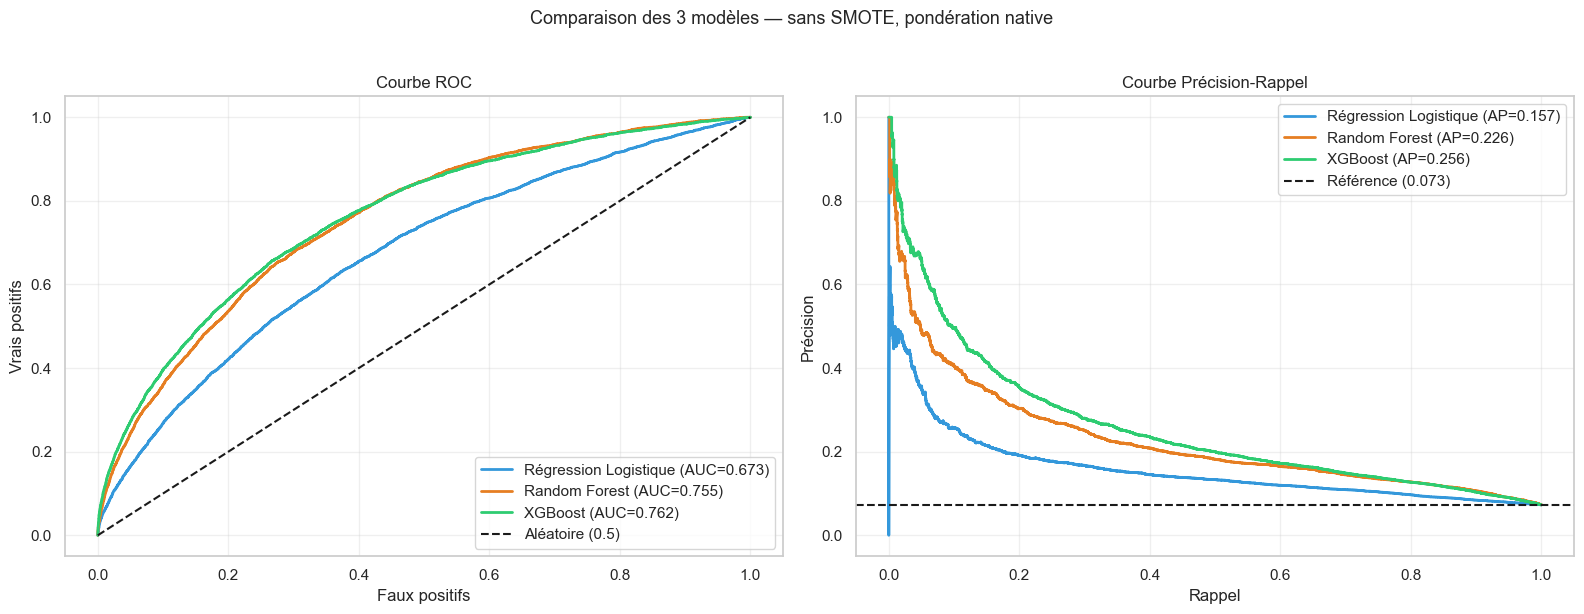

Les courbes PR sont plus informatives que ROC pour un dataset
déséquilibré à 7.3% de positifs — c'est PR-AUC
qu'on utilise comme métrique principale de comparaison.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
 
# Palette de couleurs cohérente pour les 3 modèles
couleurs = {
    'Régression Logistique': '#3498db',
    'Random Forest':         '#e67e22',
    'XGBoost':               '#2ecc71',
}
 
# ── Courbe ROC (gauche) ──────────────────────────────────────
for nom, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax1.plot(fpr, tpr, color=couleurs[nom], lw=2,
             label=f"{nom} (AUC={res['AUC-ROC']:.3f})")
 
ax1.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aléatoire (0.5)')
ax1.set_xlabel('Faux positifs')
ax1.set_ylabel('Vrais positifs')
ax1.set_title('Courbe ROC')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
 
# ── Courbe Précision-Rappel (droite) ─────────────────────────
ref_pr = y_test.mean()   # baseline = taux d'annulation réel
 
for nom, res in results.items():
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, res['proba'])
    ax2.plot(rec_curve, prec_curve, color=couleurs[nom], lw=2,
             label=f"{nom} (AP={res['PR-AUC']:.3f})")
 
ax2.axhline(ref_pr, ls='--', color='k', lw=1.5,
            label=f'Référence ({ref_pr:.3f})')
ax2.set_xlabel('Rappel')
ax2.set_ylabel('Précision')
ax2.set_title('Courbe Précision-Rappel')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
 
plt.suptitle('Comparaison des 3 modèles — sans SMOTE, pondération native',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/08_courbes_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("Les courbes PR sont plus informatives que ROC pour un dataset")
print(f"déséquilibré à {ref_pr*100:.1f}% de positifs — c'est PR-AUC")
print("qu'on utilise comme métrique principale de comparaison.")

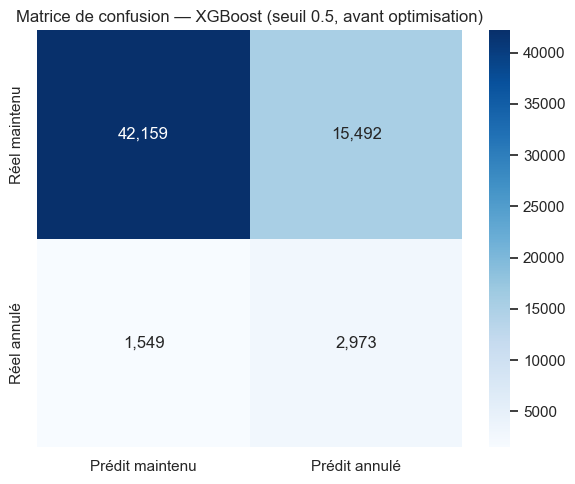

              precision    recall  f1-score   support

Maintenu (0)       0.96      0.73      0.83     57651
  Annulé (1)       0.16      0.66      0.26      4522

    accuracy                           0.73     62173
   macro avg       0.56      0.69      0.55     62173
weighted avg       0.91      0.73      0.79     62173



In [13]:
y_pred_xgb  = results['XGBoost']['pred']
y_proba_xgb = results['XGBoost']['proba']
cm_base = confusion_matrix(y_test, y_pred_xgb)
 
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_base, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Prédit maintenu', 'Prédit annulé'],
            yticklabels=['Réel maintenu',   'Réel annulé'], ax=ax)
ax.set_title('Matrice de confusion — XGBoost (seuil 0.5, avant optimisation)')
plt.tight_layout()
plt.savefig('figures/09_confusion_xgb_base.png', dpi=150)
plt.show()
 
print(classification_report(y_test, y_pred_xgb,
      target_names=['Maintenu (0)', 'Annulé (1)']))

In [14]:
# ══════════════════════════════════════════════════════════════
# CACHE DU RANDOMIZEDSEARCHCV
# Si le modèle optimisé existe déjà, on le charge directement
# au lieu de relancer 300 fits (89 min → 2 secondes).
# Pour forcer un réentraînement, supprime le fichier .joblib.
# ══════════════════════════════════════════════════════════════

import joblib
import os

CACHE_PATH = 'models/xgboost_search_cache.joblib'

if os.path.exists(CACHE_PATH):
    print("✔ Modèle optimisé trouvé en cache — chargement direct")
    search = joblib.load(CACHE_PATH)
    print(f"  Meilleur PR-AUC CV : {search.best_score_:.4f}")
    print(f"  Pas besoin de relancer les 300 fits !")
else:
    print("⚠️ Pas de cache trouvé — lancement du RandomizedSearchCV...")
    print("  (première exécution uniquement, ~15-90 min)\n")

    # ── Ton code RandomizedSearchCV existant ici ─────────────
    search = RandomizedSearchCV(
        pipe_xgb,
        param_distributions,
        n_iter=100,
        scoring='average_precision',
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    search.fit(X_train, y_train)

    # Sauvegarde pour les prochaines exécutions
    os.makedirs('models', exist_ok=True)
    joblib.dump(search, CACHE_PATH)
    print(f"\n✔ Résultats sauvegardés dans {CACHE_PATH}")
    print(f"  Les prochaines exécutions chargeront ce fichier.")

# ── Résultats (identiques dans les deux cas) ─────────────────
print(f"\nMeilleur PR-AUC CV: {search.best_score_:.4f}")
print(f"\nMeilleurs hyperparamètres :")
for param, val in sorted(search.best_params_.items()):
    param_court = param.replace('model__', '')
    if isinstance(val, float):
        print(f"  {param_court:>22} : {val:.4f}")
    else:
        print(f"  {param_court:>22} : {val}")

best_pipe = search.best_estimator_

✔ Modèle optimisé trouvé en cache — chargement direct
  Meilleur PR-AUC CV : 0.2721
  Pas besoin de relancer les 300 fits !

Meilleur PR-AUC CV: 0.2721

Meilleurs hyperparamètres :
        colsample_bytree : 0.7954
                   gamma : 0.1525
           learning_rate : 0.0171
               max_depth : 9
        min_child_weight : 6
            n_estimators : 643
               reg_alpha : 0.6533
              reg_lambda : 2.5697
               subsample : 0.7086


## 7. Optimisation des hyperparamètres (XGBoost)
**RandomizedSearchCV** — scoré sur PR-AUC, validation croisée 3-fold.
> Durée estimée : 10-20 min

In [15]:
# ══════════════════════════════════════════════════════════════
# OPTIMISATION DES HYPERPARAMÈTRES (avec cache)
# ══════════════════════════════════════════════════════════════

import joblib
import os
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform

CACHE_PATH = 'models/xgboost_search_cache.joblib'
os.makedirs('models', exist_ok=True)

if os.path.exists(CACHE_PATH):
    print("✔ Modèle optimisé trouvé en cache — chargement direct")
    search = joblib.load(CACHE_PATH)
    print(f"  Meilleur PR-AUC CV : {search.best_score_:.4f}")
else:
    print("⚠️ Pas de cache — lancement du RandomizedSearchCV...")
    print("  (première exécution uniquement, ~15-90 min)\n")

    # ── Pipeline XGBoost ─────────────────────────────────────
    pipe_xgb = Pipeline([
        ('prep',  preprocessor),
        ('model', XGBClassifier(
            scale_pos_weight=ratio_poids,
            random_state=42,
            eval_metric='aucpr',
            n_jobs=-1,
        )),
    ])

    # ── Espace de recherche ──────────────────────────────────
    param_distributions = {
        'model__n_estimators':     randint(200, 800),
        'model__max_depth':        randint(4, 10),
        'model__learning_rate':    uniform(0.01, 0.19),
        'model__subsample':        uniform(0.6, 0.4),
        'model__colsample_bytree': uniform(0.5, 0.5),
        'model__min_child_weight': randint(1, 10),
        'model__gamma':            uniform(0, 5),
        'model__reg_alpha':        uniform(0, 2),
        'model__reg_lambda':       uniform(0.5, 2.5),
    }

    search = RandomizedSearchCV(
        pipe_xgb,
        param_distributions,
        n_iter=100,
        scoring='average_precision',
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    search.fit(X_train, y_train)

    joblib.dump(search, CACHE_PATH)
    print(f"\n✔ Sauvegardé dans {CACHE_PATH}")

# ── Résultats ────────────────────────────────────────────────
best_pipe = search.best_estimator_

print(f"\nMeilleur PR-AUC CV: {search.best_score_:.4f}")
print(f"\nMeilleurs hyperparamètres :")
for param, val in sorted(search.best_params_.items()):
    p = param.replace('model__', '')
    print(f"  {p:>22} : {val:.4f}" if isinstance(val, float)
          else f"  {p:>22} : {val}")

# ── Contrôle overfitting ─────────────────────────────────────
idx_best = search.best_index_
train_sc = search.cv_results_['mean_train_score'][idx_best]
test_sc  = search.cv_results_['mean_test_score'][idx_best]
gap = train_sc - test_sc

print(f"\nContrôle overfitting :")
print(f"  PR-AUC train (CV) : {train_sc:.4f}")
print(f"  PR-AUC test  (CV) : {test_sc:.4f}")
print(f"  Écart             : {gap:.4f}", end='')
print("  ⚠️ Overfitting possible" if gap > 0.05
      else "  ✔ OK")

✔ Modèle optimisé trouvé en cache — chargement direct
  Meilleur PR-AUC CV : 0.2721

Meilleur PR-AUC CV: 0.2721

Meilleurs hyperparamètres :
        colsample_bytree : 0.7954
                   gamma : 0.1525
           learning_rate : 0.0171
               max_depth : 9
        min_child_weight : 6
            n_estimators : 643
               reg_alpha : 0.6533
              reg_lambda : 2.5697
               subsample : 0.7086

Contrôle overfitting :
  PR-AUC train (CV) : 0.4874
  PR-AUC test  (CV) : 0.2721
  Écart             : 0.2153  ⚠️ Overfitting possible


In [16]:
# %%
# ══════════════════════════════════════════════════════════════
# CELLULE 4 — Évaluation du XGBoost optimisé sur le test set
# Je compare le modèle optimisé au baseline pour mesurer
# le gain apporté par le tuning.
# ══════════════════════════════════════════════════════════════
 
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix)
import seaborn as sns
 
best_pipe = search.best_estimator_
 
y_proba_opt = best_pipe.predict_proba(X_test)[:, 1]
y_pred_opt  = best_pipe.predict(X_test)
 
auc_opt  = roc_auc_score(y_test, y_proba_opt)
pr_opt   = average_precision_score(y_test, y_proba_opt)
f1_opt   = f1_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt)
rec_opt  = recall_score(y_test, y_pred_opt)
 
# ── Comparaison baseline vs optimisé ─────────────────────────
print(f"{'='*55}")
print(f"  XGBoost : BASELINE vs OPTIMISÉ")
print(f"{'='*55}")
print(f"{'Métrique':>18} {'Baseline':>10} {'Optimisé':>10} {'Δ':>8}")
print(f"{'-'*55}")
 
metrics_base = results['XGBoost']
for metric_name, base_val, opt_val in [
    ('AUC-ROC',   metrics_base['AUC-ROC'],   auc_opt),
    ('PR-AUC',    metrics_base['PR-AUC'],     pr_opt),
    ('F1',        metrics_base['F1'],         f1_opt),
    ('Précision', metrics_base['Précision'],  prec_opt),
    ('Rappel',    metrics_base['Rappel'],     rec_opt),
]:
    delta = opt_val - base_val
    signe = '+' if delta >= 0 else ''
    print(f"{metric_name:>18} {base_val:>10.4f} {opt_val:>10.4f} {signe}{delta:>7.4f}")

  XGBoost : BASELINE vs OPTIMISÉ
          Métrique   Baseline   Optimisé        Δ
-------------------------------------------------------
           AUC-ROC     0.7619     0.7644 + 0.0025
            PR-AUC     0.2558     0.2626 + 0.0068
                F1     0.2587     0.2657 + 0.0070
         Précision     0.1610     0.1685 + 0.0075
            Rappel     0.6575     0.6269 -0.0305


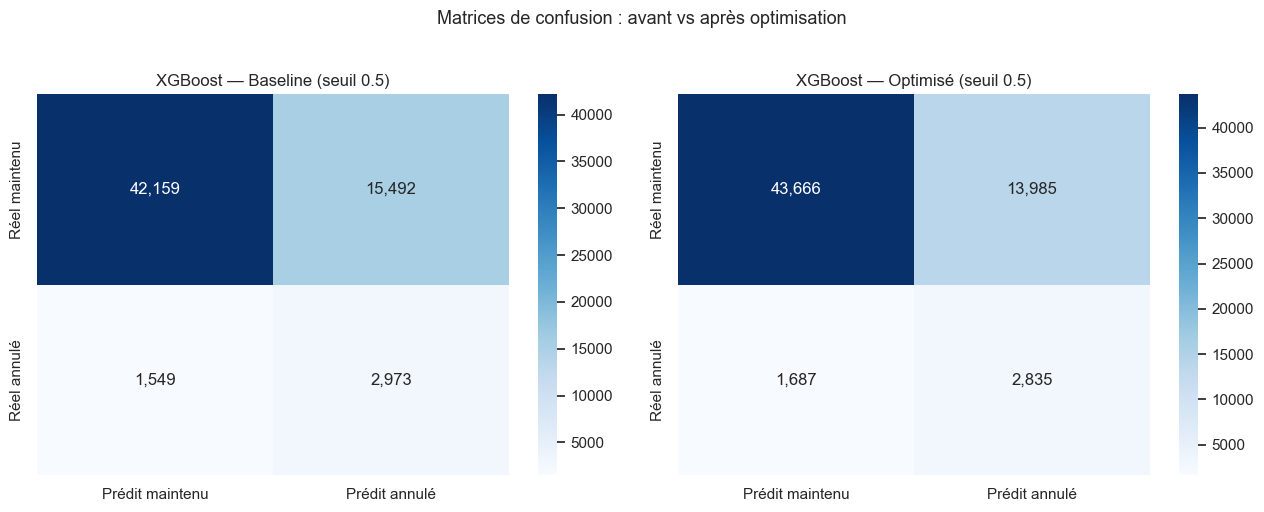


              precision    recall  f1-score   support

Maintenu (0)       0.96      0.76      0.85     57651
  Annulé (1)       0.17      0.63      0.27      4522

    accuracy                           0.75     62173
   macro avg       0.57      0.69      0.56     62173
weighted avg       0.91      0.75      0.81     62173



In [17]:
# ── Matrice de confusion optimisée ───────────────────────────
cm_opt = confusion_matrix(y_test, y_pred_opt)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
for ax, cm, titre in zip(axes,
                          [cm_base, cm_opt],
                          ['Baseline (seuil 0.5)', 'Optimisé (seuil 0.5)']):
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
                xticklabels=['Prédit maintenu', 'Prédit annulé'],
                yticklabels=['Réel maintenu',   'Réel annulé'], ax=ax)
    ax.set_title(f'XGBoost — {titre}')
 
plt.suptitle('Matrices de confusion : avant vs après optimisation',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/10_confusion_baseline_vs_opt.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f"\n{classification_report(y_test, y_pred_opt, target_names=['Maintenu (0)', 'Annulé (1)'])}")
 

=== IMPACT DU SEUIL SUR LES MÉTRIQUES ===
Total annulations réelles dans le test : 4,522

 Seuil  Rappel  Précision     F1  N alertes  Annul. captées  Annul. ratées
  0.05  0.9985     0.0737 0.1372      61303            4515              7
  0.10  0.9867     0.0782 0.1449      57048            4462             60
  0.15  0.9670     0.0857 0.1574      51056            4373            149
  0.20  0.9368     0.0940 0.1708      45086            4236            286
  0.25  0.9049     0.1034 0.1857      39556            4092            430
  0.30  0.8658     0.1143 0.2020      34241            3915            607
  0.35  0.8140     0.1256 0.2176      29307            3681            841
  0.40  0.7572     0.1383 0.2338      24764            3424           1098
  0.45  0.6920     0.1518 0.2489      20616            3129           1393
  0.50  0.6269     0.1685 0.2657      16820            2835           1687

Seuil optimal — max F1         : 0.5
Seuil optimal — rappel ≥ 60%  : 0.5
Seuil optim

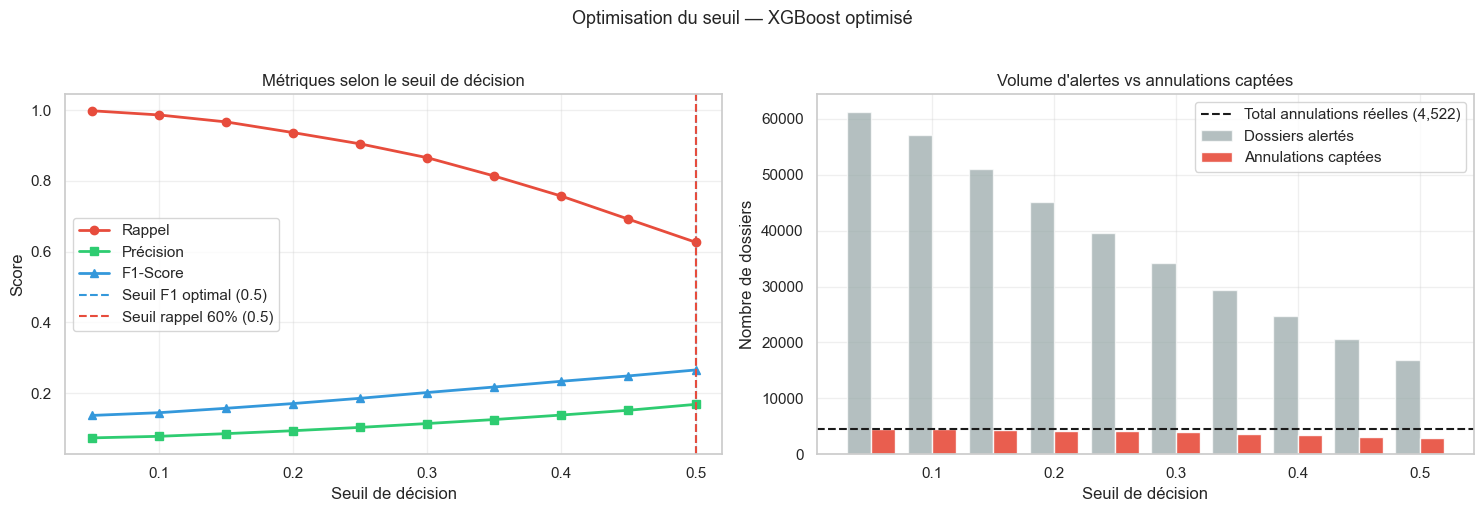

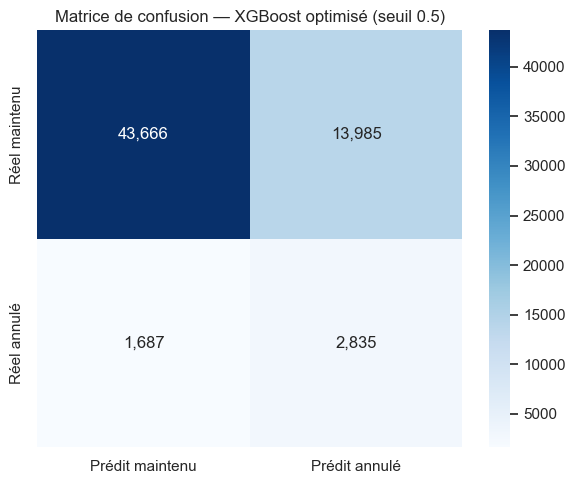


=== RÉSULTAT FINAL — SEUIL RETENU : 0.5 ===
              precision    recall  f1-score   support

Maintenu (0)       0.96      0.76      0.85     57651
  Annulé (1)       0.17      0.63      0.27      4522

    accuracy                           0.75     62173
   macro avg       0.57      0.69      0.56     62173
weighted avg       0.91      0.75      0.81     62173

Annulations captées   : 2,835 / 4,522 (62.7%)
Fausses alertes       : 13,985
Annulations ratées    : 1,687

→ Ce seuil sera utilisé dans l'application Streamlit
  pour scorer les nouvelles réservations en temps réel.


In [18]:
# %%
# ══════════════════════════════════════════════════════════════
# CELLULE 5 — Optimisation du seuil de décision
# Le seuil par défaut (0.5) est trop conservateur pour un
# cas de rétention : on préfère déclencher une alerte à tort
# (faux positif) plutôt que de rater une vraie annulation.
# ══════════════════════════════════════════════════════════════
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report)
import seaborn as sns
 
n_annul_reels = y_test.sum()
 
# ── 1. Tableau des seuils ────────────────────────────────────
seuils = np.arange(0.05, 0.55, 0.05)
rows = []
 
for s in seuils:
    pred_s  = (y_proba_opt >= s).astype(int)
    rec     = recall_score(y_test, pred_s)
    prec    = precision_score(y_test, pred_s, zero_division=0)
    f1      = f1_score(y_test, pred_s)
    n_alert = pred_s.sum()
    vp      = ((pred_s == 1) & (y_test == 1)).sum()
 
    rows.append({
        'Seuil':          round(s, 2),
        'Rappel':         round(rec, 4),
        'Précision':      round(prec, 4),
        'F1':             round(f1, 4),
        'N alertes':      int(n_alert),
        'Annul. captées': int(vp),
        'Annul. ratées':  int(n_annul_reels - vp),
    })
 
df_seuils = pd.DataFrame(rows)
print('=== IMPACT DU SEUIL SUR LES MÉTRIQUES ===')
print(f'Total annulations réelles dans le test : {n_annul_reels:,}\n')
print(df_seuils.to_string(index=False))
 
# ── 2. Seuils optimaux selon différents objectifs ────────────
seuil_f1    = df_seuils.loc[df_seuils['F1'].idxmax(), 'Seuil']
 
cand_60     = df_seuils[df_seuils['Rappel'] >= 0.60]
seuil_rec60 = (cand_60.loc[cand_60['Précision'].idxmax(), 'Seuil']
               if len(cand_60) else None)
 
cand_50     = df_seuils[df_seuils['Rappel'] >= 0.50]
seuil_rec50 = (cand_50.loc[cand_50['Précision'].idxmax(), 'Seuil']
               if len(cand_50) else None)
 
print(f'\nSeuil optimal — max F1         : {seuil_f1}')
print(f'Seuil optimal — rappel ≥ 60%  : {seuil_rec60}')
print(f'Seuil optimal — rappel ≥ 50%  : {seuil_rec50}')
 
# ── 3. Visualisation ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
 
# Gauche : métriques selon le seuil
ax1.plot(df_seuils['Seuil'], df_seuils['Rappel'],    'o-',
         color='#e74c3c', lw=2, label='Rappel')
ax1.plot(df_seuils['Seuil'], df_seuils['Précision'], 's-',
         color='#2ecc71', lw=2, label='Précision')
ax1.plot(df_seuils['Seuil'], df_seuils['F1'],        '^-',
         color='#3498db', lw=2, label='F1-Score')
ax1.axvline(seuil_f1, ls='--', c='#3498db', lw=1.5,
            label=f'Seuil F1 optimal ({seuil_f1})')
if seuil_rec60:
    ax1.axvline(seuil_rec60, ls='--', c='#e74c3c', lw=1.5,
                label=f'Seuil rappel 60% ({seuil_rec60})')
ax1.set_xlabel('Seuil de décision')
ax1.set_ylabel('Score')
ax1.set_title('Métriques selon le seuil de décision')
ax1.legend(loc='center left')
ax1.set_xlim(0.03, 0.52)
ax1.grid(True, alpha=0.3)
 
# Droite : volumes
ax2.bar(df_seuils['Seuil'] - 0.01, df_seuils['N alertes'],
        width=0.02, color='#95a5a6', label='Dossiers alertés', alpha=0.7)
ax2.bar(df_seuils['Seuil'] + 0.01, df_seuils['Annul. captées'],
        width=0.02, color='#e74c3c', label='Annulations captées', alpha=0.9)
ax2.axhline(n_annul_reels, ls='--', c='k', lw=1.5,
            label=f'Total annulations réelles ({n_annul_reels:,})')
ax2.set_xlabel('Seuil de décision')
ax2.set_ylabel('Nombre de dossiers')
ax2.set_title("Volume d'alertes vs annulations captées")
ax2.legend()
ax2.grid(True, alpha=0.3)
 
plt.suptitle('Optimisation du seuil — XGBoost optimisé', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/11_seuil_optimal.png', dpi=150, bbox_inches='tight')
plt.show()
 
# ── 4. Matrice de confusion avec le seuil retenu ────────────
# Pour la rétention, on choisit le seuil rappel ≥ 60%
# (ou F1 si le rappel ≥ 60% n'est pas atteignable)
SEUIL_RETENU = seuil_rec60 if seuil_rec60 else seuil_f1
 
pred_final = (y_proba_opt >= SEUIL_RETENU).astype(int)
cm_final   = confusion_matrix(y_test, pred_final)
 
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Prédit maintenu', 'Prédit annulé'],
            yticklabels=['Réel maintenu',   'Réel annulé'], ax=ax)
ax.set_title(f'Matrice de confusion — XGBoost optimisé (seuil {SEUIL_RETENU})')
plt.tight_layout()
plt.savefig('figures/12_confusion_seuil_retenu.png', dpi=150)
plt.show()
 
print(f'\n=== RÉSULTAT FINAL — SEUIL RETENU : {SEUIL_RETENU} ===')
print(classification_report(y_test, pred_final,
      target_names=['Maintenu (0)', 'Annulé (1)']))
 
vp = ((pred_final == 1) & (y_test == 1)).sum()
fp = ((pred_final == 1) & (y_test == 0)).sum()
fn = ((pred_final == 0) & (y_test == 1)).sum()
print(f"Annulations captées   : {vp:,} / {n_annul_reels:,} ({vp/n_annul_reels*100:.1f}%)")
print(f"Fausses alertes       : {fp:,}")
print(f"Annulations ratées    : {fn:,}")
print(f"\n→ Ce seuil sera utilisé dans l'application Streamlit")
print(f"  pour scorer les nouvelles réservations en temps réel.")
 

## 8. Interprétabilité SHAP — XGBoost optimisé

Calcul des valeurs SHAP sur 3,000 dossiers échantillonnés…
✔ SHAP calculé (35 features analysées)

── SHAP Summary Plot (importance globale) ──


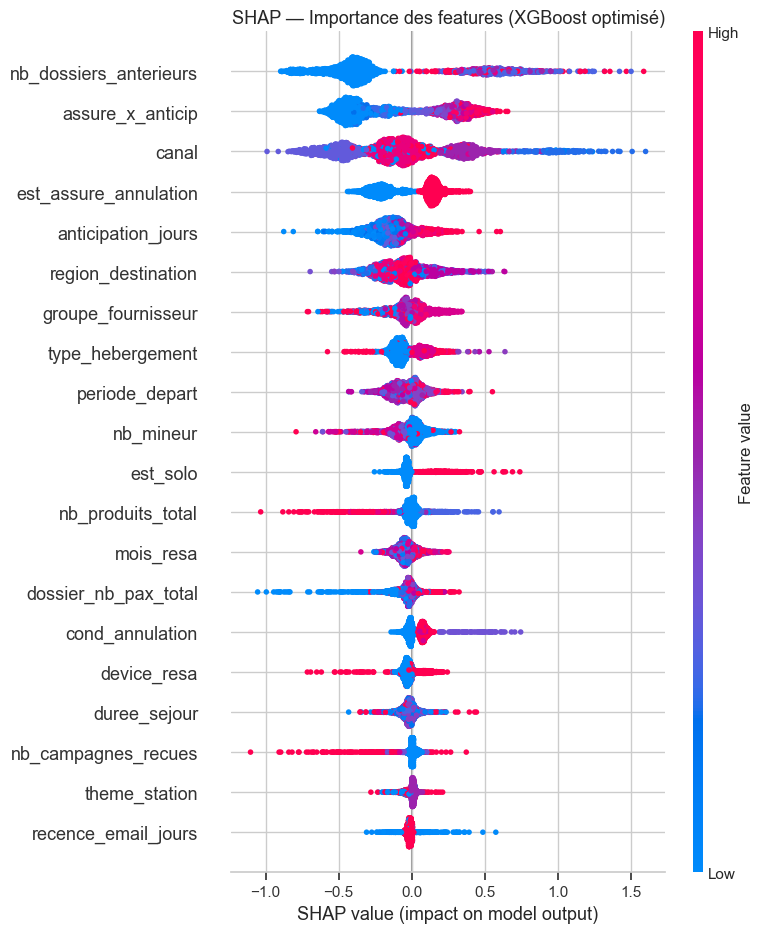


── SHAP Bar Plot (importance moyenne) ──


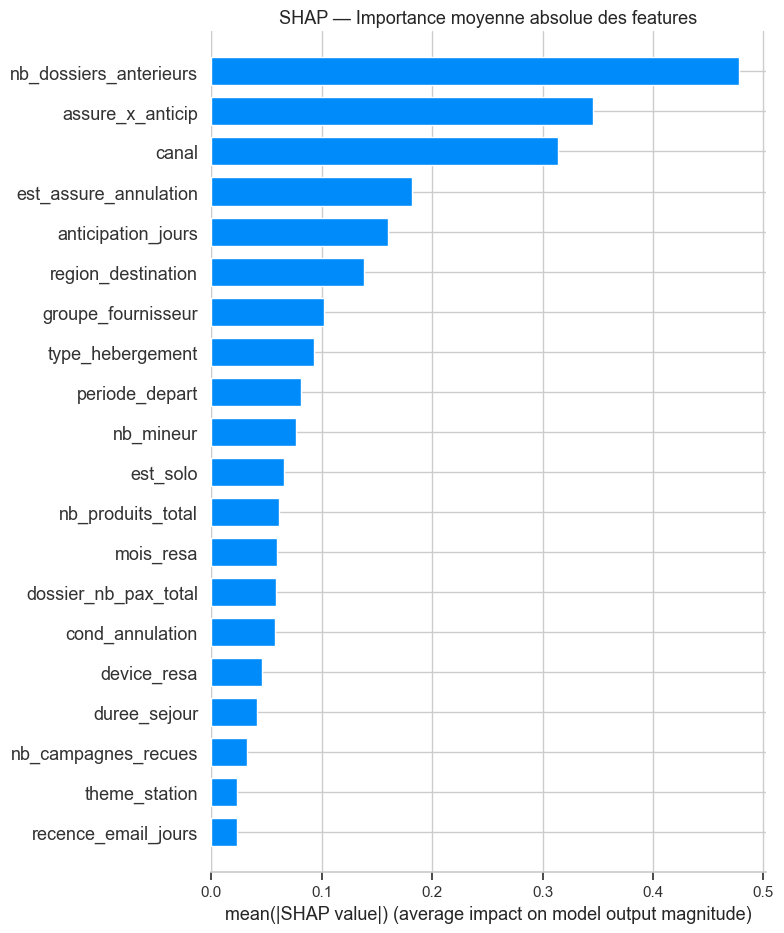


── SHAP Dependence Plots (top 5 features) ──


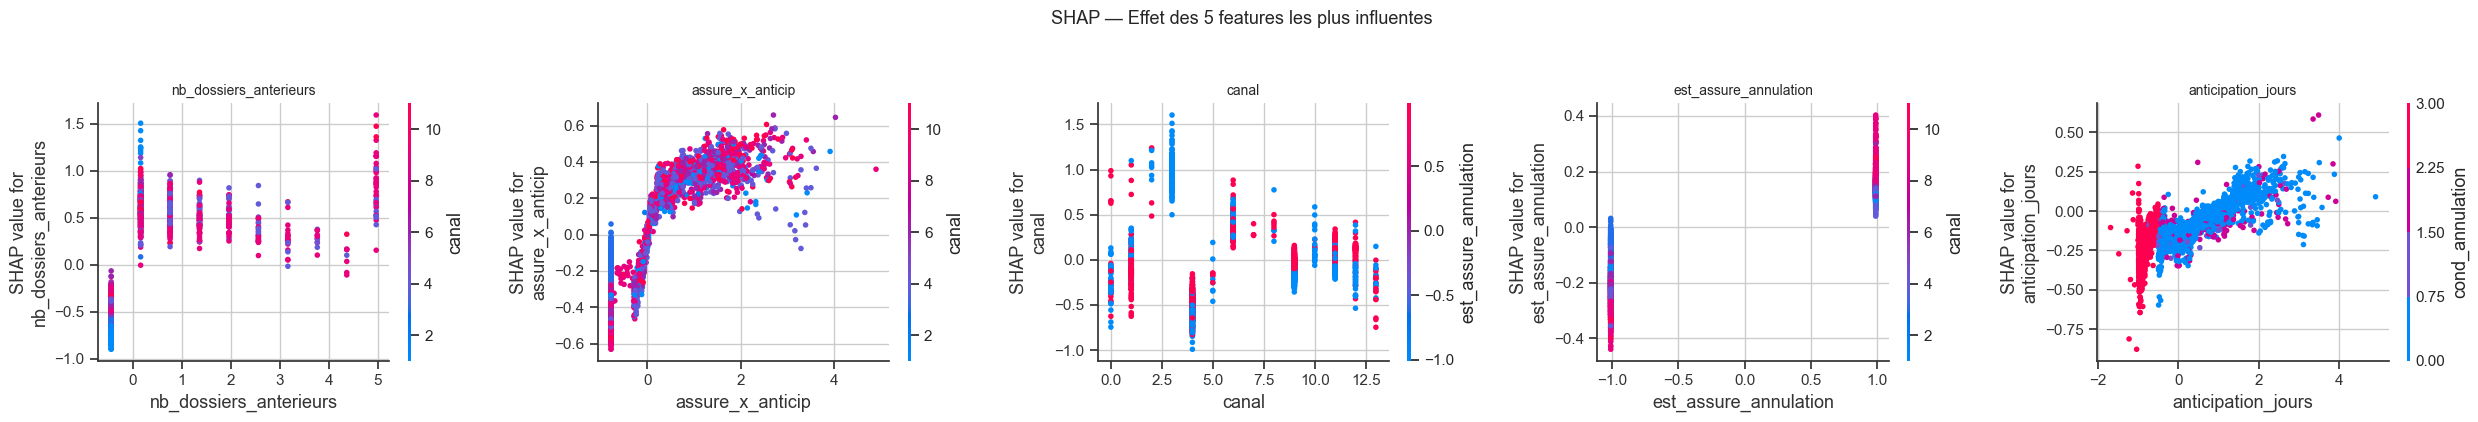


── SHAP Waterfall (exemples individuels) ──


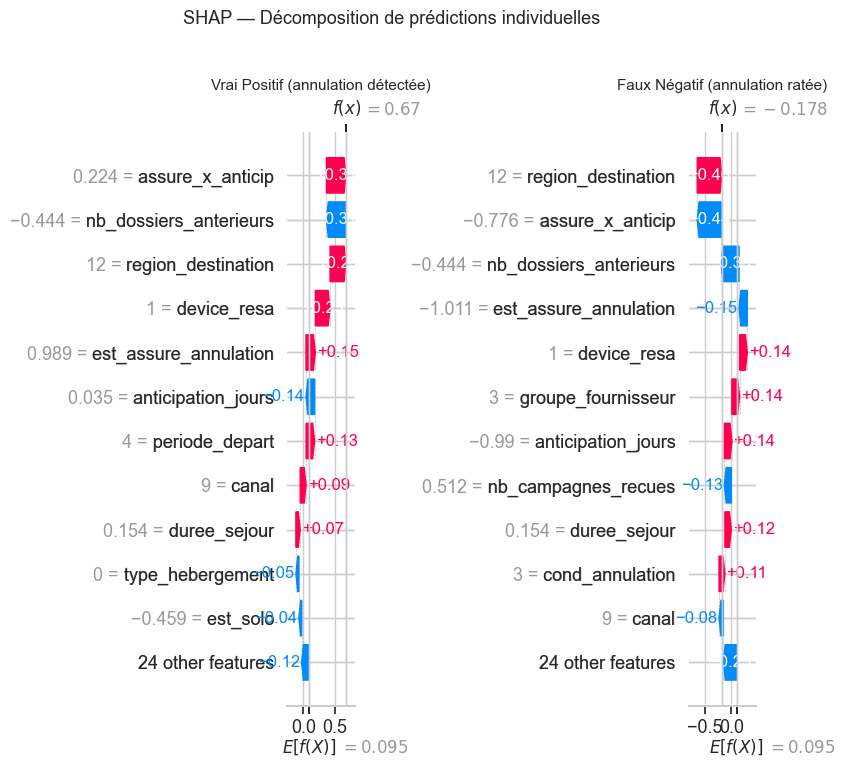


  SYNTHÈSE SHAP — TOP 10 FEATURES
   1. nb_dossiers_anterieurs         (|SHAP| moyen = 0.4783)
   2. assure_x_anticip               (|SHAP| moyen = 0.3457)
   3. canal                          (|SHAP| moyen = 0.3142)
   4. est_assure_annulation          (|SHAP| moyen = 0.1816)
   5. anticipation_jours             (|SHAP| moyen = 0.1603)
   6. region_destination             (|SHAP| moyen = 0.1379)
   7. groupe_fournisseur             (|SHAP| moyen = 0.1016)
   8. type_hebergement               (|SHAP| moyen = 0.0929)
   9. periode_depart                 (|SHAP| moyen = 0.0810)
  10. nb_mineur                      (|SHAP| moyen = 0.0771)

→ Ces résultats alimenteront la section 'Interprétabilité'
  du mémoire et les recommandations métier.


In [19]:
# %%
# ══════════════════════════════════════════════════════════════
# CELLULE 6 — Interprétabilité SHAP — XGBoost optimisé
# SHAP attribue à chaque feature sa contribution à la prédiction.
# Indispensable pour expliquer au métier POURQUOI un dossier
# est à risque.
#
# ⚡ Optimisation : calculer SHAP sur les 62k lignes du test prend
# plusieurs dizaines de minutes. L'importance globale est déjà
# parfaitement stable sur un échantillon aléatoire — on calcule
# donc SHAP sur N_SHAP dossiers tirés au hasard (seed fixe).
# ══════════════════════════════════════════════════════════════

import shap

# ── Extraction du modèle XGBoost depuis le pipeline ──────────
xgb_model = best_pipe.named_steps['model']
X_test_transformed = best_pipe.named_steps['prep'].transform(X_test)
feature_names = FEATURES_NUM + FEATURES_CAT

# ── Échantillonnage pour accélérer SHAP ──────────────────────
N_SHAP = 3000                      # suffisant pour une importance stable
rng  = np.random.RandomState(42)
samp = rng.choice(X_test_transformed.shape[0],
                  size=min(N_SHAP, X_test_transformed.shape[0]),
                  replace=False)
X_shap = X_test_transformed[samp]

print(f"Calcul des valeurs SHAP sur {X_shap.shape[0]:,} dossiers échantillonnés…")
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)
print(f"✔ SHAP calculé ({X_shap.shape[1]} features analysées)")

# ── 1. Summary plot (beeswarm) — importance globale ──────────
print("\n── SHAP Summary Plot (importance globale) ──")
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  max_display=20, show=False)
plt.title('SHAP — Importance des features (XGBoost optimisé)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/13_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Bar plot — importance moyenne absolue ─────────────────
print("\n── SHAP Bar Plot (importance moyenne) ──")
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP — Importance moyenne absolue des features', fontsize=13)
plt.tight_layout()
plt.savefig('figures/14_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Top 5 features — dependence plots ────────────────────
print("\n── SHAP Dependence Plots (top 5 features) ──")
shap_importance = np.abs(shap_values).mean(axis=0)
top5_idx   = np.argsort(shap_importance)[-5:][::-1]
top5_names = [feature_names[i] for i in top5_idx]
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for ax, idx, name in zip(axes, top5_idx, top5_names):
    shap.dependence_plot(idx, shap_values, X_shap,
                         feature_names=feature_names, ax=ax, show=False)
    ax.set_title(name, fontsize=10)
plt.suptitle('SHAP — Effet des 5 features les plus influentes',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig('figures/15_shap_dependence_top5.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Waterfall — explication d'une prédiction individuelle ─
# Vrai positif + faux négatif : SHAP calculé à la volée sur ces
# 2 lignes seulement (instantané).
print("\n── SHAP Waterfall (exemples individuels) ──")
vp_indices = y_test[(y_test == 1) & (pred_final == 1)].index.tolist()
fn_indices = y_test[(y_test == 1) & (pred_final == 0)].index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
for ax_idx, (indices, titre) in enumerate([
    (vp_indices, 'Vrai Positif (annulation détectée)'),
    (fn_indices, 'Faux Négatif (annulation ratée)')
]):
    if not indices:
        continue
    pos    = X_test.index.get_loc(indices[0])
    sv_one = explainer.shap_values(X_test_transformed[pos:pos+1])[0]
    plt.sca(axes[ax_idx])
    explanation = shap.Explanation(
        values=sv_one,
        base_values=explainer.expected_value,
        data=X_test_transformed[pos],
        feature_names=feature_names
    )
    shap.waterfall_plot(explanation, max_display=12, show=False)
    axes[ax_idx].set_title(titre, fontsize=11)
plt.suptitle('SHAP — Décomposition de prédictions individuelles',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/16_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Synthèse SHAP pour le mémoire ────────────────────────
print("\n" + "="*55)
print("  SYNTHÈSE SHAP — TOP 10 FEATURES")
print("="*55)
top10_idx = np.argsort(shap_importance)[-10:][::-1]
for rank, idx in enumerate(top10_idx, 1):
    print(f"  {rank:>2}. {feature_names[idx]:<30} "
          f"(|SHAP| moyen = {shap_importance[idx]:.4f})")
print(f"\n→ Ces résultats alimenteront la section 'Interprétabilité'")
print(f"  du mémoire et les recommandations métier.")

## 9. Recalibration des probabilités

Le modèle est entraîné avec `scale_pos_weight ≈ 12.75` pour compenser le
déséquilibre (7,3 % d'annulations). Ce paramètre améliore le rappel mais
**déforme les probabilités** : le modèle sur-estime systématiquement le risque
(un score de 0.50 correspond en réalité à ~10 % de chance d'annuler). Les scores
sont donc utilisables pour *classer* les dossiers (l'AUC reste bonne) mais pas
comme *probabilités* interprétables — ce qui fausse toute estimation de CA
sauvé côté application.

Je recalibre **a posteriori**, sans ré-entraîner le modèle final :

1. probabilités *out-of-fold* sur le train (`cross_val_predict`) → aucune fuite ;
2. ajustement d'un calibrateur 1-D (isotonique vs Platt) : proba brute → proba réelle ;
3. application au test et comparaison (score de Brier, courbe de fiabilité).

La recalibration étant **monotone**, l'AUC-ROC est préservée : seule l'échelle
des probabilités change.

In [20]:
# ─────────────────────────────────────────────────────────────
# 6.1 — Ajustement des calibrateurs (out-of-fold, sans fuite)
# ─────────────────────────────────────────────────────────────
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

cv_cal = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Probabilités out-of-fold sur le train (peut prendre quelques minutes)…")
oof_proba = cross_val_predict(clone(best_pipe), X_train, y_train,
                              cv=cv_cal, method='predict_proba')[:, 1]

# Calibrateur isotonique (non paramétrique, bien adapté aux arbres)
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(oof_proba, y_train)

# Calibrateur de Platt (sigmoïde) pour comparaison
platt = LogisticRegression()
platt.fit(oof_proba.reshape(-1, 1), y_train)

# Application au TEST (y_proba_opt = probas brutes de best_pipe sur X_test)
proba_iso   = iso.predict(y_proba_opt)
proba_platt = platt.predict_proba(y_proba_opt.reshape(-1, 1))[:, 1]

brier_brut  = brier_score_loss(y_test, y_proba_opt)
brier_iso   = brier_score_loss(y_test, proba_iso)
brier_platt = brier_score_loss(y_test, proba_platt)

print(f"\nScore de Brier (plus bas = mieux) :")
print(f"  Brut (scale_pos_weight) : {brier_brut:.4f}")
print(f"  Isotonique              : {brier_iso:.4f}")
print(f"  Platt (sigmoïde)        : {brier_platt:.4f}")

# L'AUC-ROC doit rester identique (transformation monotone)
print(f"\nAUC-ROC  brut : {roc_auc_score(y_test, y_proba_opt):.4f}"
      f"  |  isotonique : {roc_auc_score(y_test, proba_iso):.4f}")

# Sélection du meilleur calibrateur (Brier minimal)
if brier_iso <= brier_platt:
    calibrateur, proba_cal, nom_cal = iso, proba_iso, 'isotonic'
else:
    calibrateur, proba_cal, nom_cal = platt, proba_platt, 'platt'
print(f"\n→ Calibrateur retenu : {nom_cal}  (Brier {min(brier_iso, brier_platt):.4f})")

Probabilités out-of-fold sur le train (peut prendre quelques minutes)…

Score de Brier (plus bas = mieux) :
  Brut (scale_pos_weight) : 0.1665
  Isotonique              : 0.0608
  Platt (sigmoïde)        : 0.0613

AUC-ROC  brut : 0.7644  |  isotonique : 0.7641

→ Calibrateur retenu : isotonic  (Brier 0.0608)


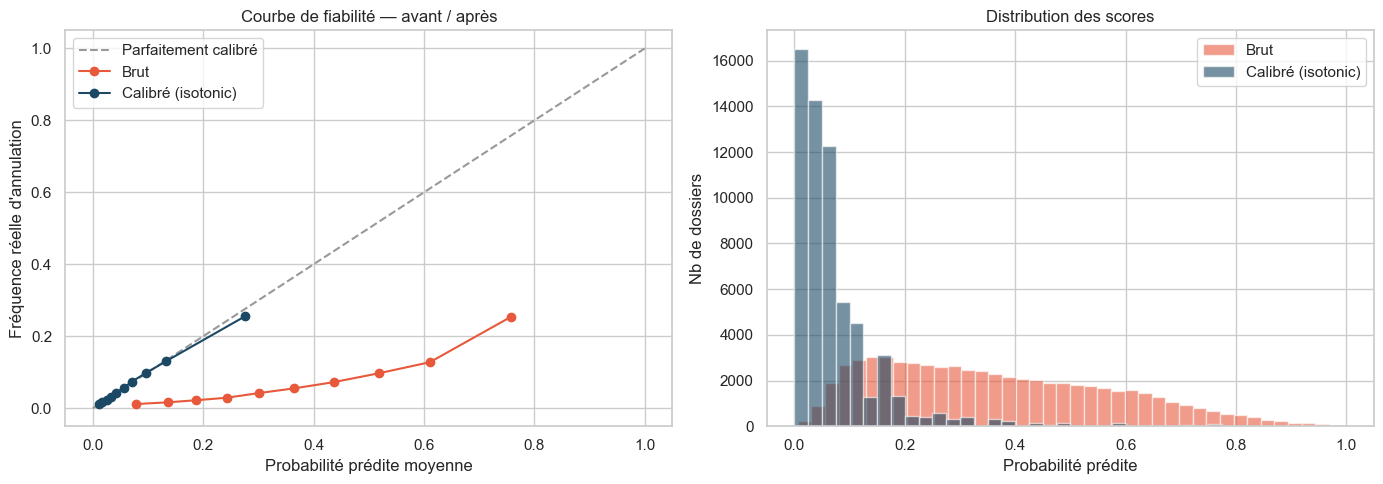

In [21]:
# ─────────────────────────────────────────────────────────────
# 6.2 — Courbe de fiabilité : avant / après recalibration
# ─────────────────────────────────────────────────────────────
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot([0, 1], [0, 1], '--', color='#999', label='Parfaitement calibré')
for proba, lab, col in [(y_proba_opt, 'Brut', '#E8593C'),
                        (proba_cal, f'Calibré ({nom_cal})', '#1b4965')]:
    fp, mp = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    axes[0].plot(mp, fp, 'o-', color=col, label=lab)
axes[0].set_xlabel('Probabilité prédite moyenne')
axes[0].set_ylabel("Fréquence réelle d'annulation")
axes[0].set_title('Courbe de fiabilité — avant / après')
axes[0].legend(loc='upper left')

axes[1].hist(y_proba_opt, bins=40, alpha=0.6, color='#E8593C', label='Brut')
axes[1].hist(proba_cal,   bins=40, alpha=0.6, color='#1b4965',
             label=f'Calibré ({nom_cal})')
axes[1].set_xlabel('Probabilité prédite'); axes[1].set_ylabel('Nb de dossiers')
axes[1].set_title('Distribution des scores'); axes[1].legend()
plt.tight_layout()
plt.savefig('figures/17_recalibration.png', dpi=150)
plt.show()

In [22]:
# ─────────────────────────────────────────────────────────────
# 6.3 — Seuil de décision sur les probabilités CALIBRÉES
# Après recalibration, un seuil s'interprète comme un vrai risque.
# Je conserve la même logique métier : meilleur précision à rappel ≥ 60 %.
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve

prec_c, rec_c, thr_c = precision_recall_curve(y_test, proba_cal)
ok = rec_c[:-1] >= 0.60
if ok.any():
    idx = int(np.argmax(prec_c[:-1] * ok))   # meilleure précision, rappel ≥ 60 %
    SEUIL_CAL = float(thr_c[idx])
else:
    f1c = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-9)
    SEUIL_CAL = float(thr_c[int(np.argmax(f1c))])

pred_cal = (proba_cal >= SEUIL_CAL).astype(int)
print(f"Seuil retenu (proba calibrée) : {SEUIL_CAL:.3f}\n")
print(classification_report(y_test, pred_cal,
      target_names=['Maintenu (0)', 'Annulé (1)']))

Seuil retenu (proba calibrée) : 0.092

              precision    recall  f1-score   support

Maintenu (0)       0.96      0.74      0.84     57651
  Annulé (1)       0.16      0.65      0.26      4522

    accuracy                           0.73     62173
   macro avg       0.56      0.69      0.55     62173
weighted avg       0.91      0.73      0.79     62173



## 10. Sauvegarde du modèle, du calibrateur & des métadonnées

In [23]:
# %%
# ══════════════════════════════════════════════════════════════
# CELLULE 7 — Sauvegarde du modèle final
# On sauvegarde le pipeline complet (preprocessing + modèle)
# et le seuil retenu pour l'application Streamlit.
# ══════════════════════════════════════════════════════════════
 
import joblib
import json
 
# ── Pipeline complet ─────────────────────────────────────────
MODEL_PATH = 'models/xgboost_optimise.joblib'
joblib.dump(best_pipe, MODEL_PATH)
print(f"✔ Pipeline sauvegardé : {MODEL_PATH}")
 
# ── Métadonnées du modèle ────────────────────────────────────
metadata = {
    'seuil_retenu':        float(SEUIL_RETENU),
    'auc_roc':             float(auc_opt),
    'pr_auc':              float(pr_opt),
    'f1_seuil_05':         float(f1_opt),
    'rappel_seuil_retenu': float(recall_score(y_test, pred_final)),
    'precision_seuil_retenu': float(precision_score(y_test, pred_final)),
    'features_num':        FEATURES_NUM,
    'features_cat':        FEATURES_CAT,
    'n_train':             int(len(X_train)),
    'n_test':              int(len(X_test)),
    'taux_annulation':     float(y_test.mean()),
    'best_params':         {k.replace('model__', ''): (float(v) if isinstance(v, (float, np.floating))
                            else int(v) if isinstance(v, (int, np.integer))
                            else v)
                            for k, v in search.best_params_.items()},
}
 
META_PATH = 'models/model_metadata.json'
with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"✔ Métadonnées sauvegardées : {META_PATH}")
 
print(f"\n{'='*50}")
print(f"  PIPELINE COMPLET TERMINÉ")
print(f"{'='*50}")
print(f"  Modèle       : XGBoost optimisé (RandomizedSearchCV)")
print(f"  Seuil retenu : {SEUIL_RETENU}")
print(f"  AUC-ROC      : {auc_opt:.4f}")
print(f"  PR-AUC       : {pr_opt:.4f}")
print(f"  Figures       : ./figures/08 à 16")
print(f"  Modèle        : {MODEL_PATH}")
print(f"  Métadonnées   : {META_PATH}")
print(f"\n→ Prochaine étape : application Streamlit (app.py)")

✔ Pipeline sauvegardé : models/xgboost_optimise.joblib
✔ Métadonnées sauvegardées : models/model_metadata.json

  PIPELINE COMPLET TERMINÉ
  Modèle       : XGBoost optimisé (RandomizedSearchCV)
  Seuil retenu : 0.5
  AUC-ROC      : 0.7644
  PR-AUC       : 0.2626
  Figures       : ./figures/08 à 16
  Modèle        : models/xgboost_optimise.joblib
  Métadonnées   : models/model_metadata.json

→ Prochaine étape : application Streamlit (app.py)


In [24]:
# ─────────────────────────────────────────────────────────────
# 6.4 — Sauvegarde du calibrateur + enrichissement des métadonnées
# best_pipe (non calibré) reste sauvegardé tel quel pour l'introspection
# et SHAP côté application ; le calibrateur est un artefact 1-D distinct
# que l'appli peut appliquer par-dessus predict_proba.
# ─────────────────────────────────────────────────────────────
CALIB_PATH = 'models/calibrateur.joblib'
joblib.dump({'calibrateur': calibrateur, 'methode': nom_cal}, CALIB_PATH)
print(f"✔ Calibrateur sauvegardé : {CALIB_PATH}")

with open(META_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)
metadata['calibration'] = {
    'methode':         nom_cal,
    'brier_brut':      float(brier_brut),
    'brier_calibre':   float(min(brier_iso, brier_platt)),
    'seuil_calibre':   float(SEUIL_CAL),
    'rappel_calibre':  float(recall_score(y_test, pred_cal)),
    'precision_calibre': float(precision_score(y_test, pred_cal)),
}
with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"✔ Métadonnées enrichies  : {META_PATH}")
print(f"\nBrier : {brier_brut:.4f} (brut) → {metadata['calibration']['brier_calibre']:.4f} (calibré)")

✔ Calibrateur sauvegardé : models/calibrateur.joblib
✔ Métadonnées enrichies  : models/model_metadata.json

Brier : 0.1665 (brut) → 0.0608 (calibré)


## 11. Analyse coût/bénéfice & choix du seuil de décision

Grâce aux probabilités **calibrées** (section 9), on remplace un seuil
statistique arbitraire par un seuil **économique** : on contacte un dossier tant
que le gain espéré dépasse le coût de l'action de rétention.

> Contacter si  `proba_calibrée × prix × marge × efficacité > coût_action`
> &nbsp;&nbsp;⟺&nbsp;&nbsp; seuil ≈ `coût_action / (marge × prix × efficacité)`

Les vrais coûts (taux de marge Maeva, coût d'une relance) n'étant pas encore
connus, on procède par **analyse de sensibilité** : on montre que la démarche
tient sur une gamme de scénarios plausibles.

**Hypothèses / limites :** efficacité `e = 100 %` (borne haute — le gain est
proportionnel à `e`) ; perte de marge supposée totale (les remboursements
partiels selon `cond_annulation` sont ignorés) ; résultats mesurés sur le jeu de
test (20 % des données).

In [25]:
# ══════════════════════════════════════════════════════════════
# CELLULE 8 — Analyse coût/bénéfice : gain net d'un ciblage
# Gain net (vs ne rien faire) d'une politique contactant l'ensemble S :
#   gain = e · marge · Σ(prix_i · y_i sur S)  −  coût_action · |S|
# On réutilise proba_cal (calibré, section 9), X_test, y_test.
# ══════════════════════════════════════════════════════════════

# Prix aligné sur le test via le même DataFrame que le split ; avoirs < 0 → 0
prix_test = df.loc[X_test.index, 'prix_total_ttc'].clip(lower=0).values
y_te_arr  = y_test.values if hasattr(y_test, 'values') else np.asarray(y_test)

E      = 1.0                       # efficacité de l'action (100 % = borne haute)
MARGES = {'15 %': 0.15, '20 %': 0.20, '25 %': 0.25}
COUTS  = [2, 5, 15, 30]            # € par action de rétention

prix_annule = prix_test * y_te_arr           # prix des dossiers qui annulent vraiment
grille = np.linspace(0.0, proba_cal.max(), 400)

def gain_net(seuil, marge, cout):
    S = proba_cal >= seuil
    ca_sauve = E * marge * (prix_test[S] * y_te_arr[S]).sum()
    return ca_sauve - cout * S.sum()

print('=' * 66)
print(f"  SENSIBILITÉ DU GAIN NET — test : {len(y_te_arr):,} dossiers")
print('=' * 66)
print(f"{'marge':>6} {'coût':>6} | {'seuil*':>7} {'contactés':>9} {'rappel':>7} {'GAIN NET':>12}")
for mlab, marge in MARGES.items():
    ca_perdu = marge * prix_annule.sum()
    for cout in COUTS:
        g = np.array([gain_net(t, marge, cout) for t in grille])
        j = int(np.argmax(g)); tstar = grille[j]; S = proba_cal >= tstar
        rec = y_te_arr[S].sum() / y_te_arr.sum()
        print(f"{mlab:>6} {cout:>4}€ | {tstar:7.3f} {S.sum():9,} {rec:7.1%} {g[j]:11,.0f}€")
    print(f"        → marge perdue si on ne fait rien : {ca_perdu:,.0f} €")

  SENSIBILITÉ DU GAIN NET — test : 62,173 dossiers
 marge   coût |  seuil* contactés  rappel     GAIN NET
  15 %    2€ |   0.050    31,388   83.7%     109,788€
  15 %    5€ |   0.108    12,034   51.6%      44,720€
  15 %   15€ |   0.489       414    5.9%         501€
  15 %   30€ |   0.860        32    0.7%        -879€
        → marge perdue si on ne fait rien : 201,677 €
  20 %    2€ |   0.043    34,054   86.4%     168,418€
  20 %    5€ |   0.090    18,026   64.8%      88,371€
  20 %   15€ |   0.276     1,693   15.5%       6,232€
  20 %   30€ |   0.860        32    0.7%        -852€
        → marge perdue si on ne fait rien : 268,903 €
  25 %    2€ |   0.030    41,756   92.0%     229,298€
  25 %    5€ |   0.063    24,064   74.7%     134,232€
  25 %   15€ |   0.258     2,349   19.2%      14,378€
  25 %   30€ |   0.860        32    0.7%        -825€
        → marge perdue si on ne fait rien : 336,129 €


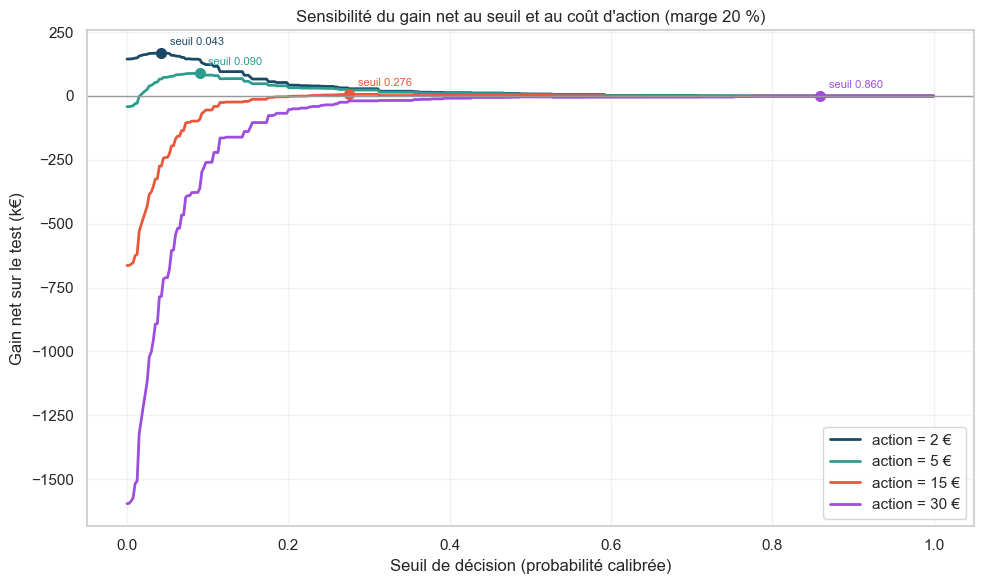

In [26]:
# ── Figure : gain net selon le seuil, pour plusieurs coûts (marge 20 %) ──
marge0 = 0.20
fig, ax = plt.subplots(figsize=(10, 6))
couleurs = ['#1b4965', '#2a9d8f', '#E8593C', '#9d4edd']
for cout, col in zip(COUTS, couleurs):
    g = np.array([gain_net(t, marge0, cout) for t in grille]) / 1000
    ax.plot(grille, g, color=col, lw=2, label=f'action = {cout} €')
    j = int(np.argmax(g))
    ax.plot(grille[j], g[j], 'o', color=col, ms=7)
    ax.annotate(f'seuil {grille[j]:.3f}', (grille[j], g[j]),
                textcoords='offset points', xytext=(6, 6), fontsize=8, color=col)
ax.axhline(0, color='#999', lw=1)
ax.set_xlabel('Seuil de décision (probabilité calibrée)')
ax.set_ylabel('Gain net sur le test (k€)')
ax.set_title(f"Sensibilité du gain net au seuil et au coût d'action (marge {int(marge0*100)} %)")
ax.legend(); ax.grid(alpha=.25)
plt.tight_layout()
plt.savefig('figures/18_sensibilite_cout_seuil.png', dpi=150, bbox_inches='tight')
plt.show()

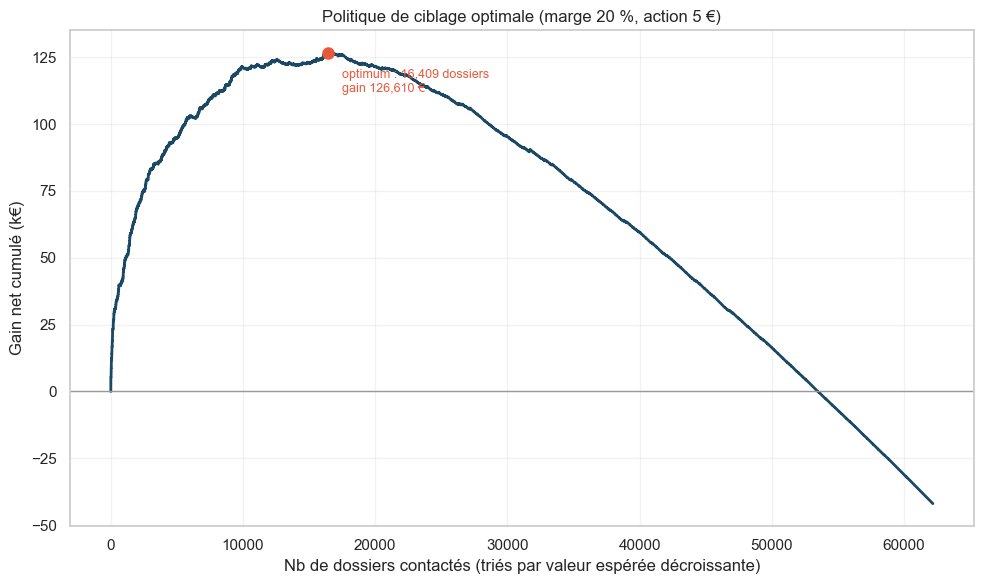


→ Règle de décision : contacter un dossier si
     proba_calibrée × prix × marge × efficacité  >  coût_action
  soit un seuil ≈ coût_action / (marge × prix × efficacité).
  La calibration (section 9) est ce qui rend ce raisonnement valide.


In [27]:
# ── Politique optimale par valeur espérée (marge 20 %, action 5 €) ──
# On trie les dossiers par (prix × proba) décroissant et on cumule le gain réel.
marge0, cout0 = 0.20, 5
esperance     = E * marge0 * prix_test * proba_cal
ordre         = np.argsort(-esperance)
gain_unitaire = E * marge0 * prix_test * y_te_arr - cout0   # gain réalisé par contact
cumul         = np.cumsum(gain_unitaire[ordre]) / 1000

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(1, len(cumul) + 1), cumul, color='#1b4965', lw=2)
k = int(np.argmax(cumul))
ax.plot(k + 1, cumul[k], 'o', color='#E8593C', ms=8)
ax.annotate(f'optimum : {k+1:,} dossiers\ngain {cumul[k]*1000:,.0f} €',
            (k + 1, cumul[k]), textcoords='offset points', xytext=(10, -28),
            fontsize=9, color='#E8593C')
ax.axhline(0, color='#999', lw=1)
ax.set_xlabel('Nb de dossiers contactés (triés par valeur espérée décroissante)')
ax.set_ylabel('Gain net cumulé (k€)')
ax.set_title(f'Politique de ciblage optimale (marge {int(marge0*100)} %, action {cout0} €)')
ax.grid(alpha=.25)
plt.tight_layout()
plt.savefig('figures/19_ciblage_valeur_esperee.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n→ Règle de décision : contacter un dossier si")
print("     proba_calibrée × prix × marge × efficacité  >  coût_action")
print("  soit un seuil ≈ coût_action / (marge × prix × efficacité).")
print("  La calibration (section 9) est ce qui rend ce raisonnement valide.")